In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

df_path = DATA_PROCESSED / "df_model_clean_v1.parquet"
rapping_path = DATA_PROCESSED / "rapping_features_v1.parquet"

df = pd.read_parquet(df_path)
rapping = pd.read_parquet(rapping_path)

print("df:", df.shape)
print("rapping:", rapping.shape)
print(df.index.min(), "→", df.index.max())

df: (210644, 76)
rapping: (210644, 3)
2025-06-30 00:00:00 → 2025-08-01 00:00:00


In [3]:
TARGET_COL = "008A01345"  # dust concentration after ESP

U_COLS = {
    "U1": "008A02289",
    "U2": "008A02290",
    "U3": "008A02291",
}

I_COLS = {
    "I1": "008A02267",
    "I2": "008A02268",
    "I3": "008A02269",
}

P_COLS = {
    "P1": "008A02273",
    "P2": "008A02274",
    "P3": "008A02275",
}

RAPPING_TIME_COL = "minutes_since_rapping_3_collecting_start_0_5"
RAPPING_FLAG_COL = "is_within_5min_after_rapping_3_collecting"

required_cols = (
    [TARGET_COL]
    + list(U_COLS.values())
    + list(I_COLS.values())
    + list(P_COLS.values())
)

missing = [col for col in required_cols if col not in df.columns]
missing

[]

In [4]:
df_ov = df.copy()

# Dołączamy cechy strzepywania, jeżeli nie ma ich jeszcze w df
rapping_cols = [RAPPING_TIME_COL, RAPPING_FLAG_COL]

df_ov = df_ov.join(
    rapping[rapping_cols],
    how="left"
)

# Suma mocy i średnie napięcie
df_ov["P_total"] = df_ov[list(P_COLS.values())].sum(axis=1)
df_ov["U_mean"] = df_ov[list(U_COLS.values())].mean(axis=1)
df_ov["U_sum"] = df_ov[list(U_COLS.values())].sum(axis=1)

# Przybliżona moc z U*I dla kontroli
for sec in ["1", "2", "3"]:
    df_ov[f"P{sec}_calc"] = (
        df_ov[U_COLS[f"U{sec}"]] * df_ov[I_COLS[f"I{sec}"]] / 1000
    )

df_ov["P_total_calc"] = df_ov[["P1_calc", "P2_calc", "P3_calc"]].sum(axis=1)

df_ov[
    [TARGET_COL, "P_total", "P_total_calc", "U_mean", "U_sum"]
].describe()

,008A01345,P_total,P_total_calc,U_mean,U_sum
count,210644.000000,210644.000000,210644.000000,210644.000000,210644.000000
mean,11.149162,39.890049,39.496097,42.333769,127.001306
std,4.822527,9.572117,9.493744,1.406155,4.218466
min,2.000000,31.200000,30.872000,37.333333,112.000000
25%,9.000000,37.900001,37.504000,41.666667,125.000000
50%,11.000000,38.299999,37.916000,42.000000,126.000000
75%,13.000000,38.700001,38.341000,42.333333,127.000000
max,101.000000,288.699997,287.868000,67.666667,203.000000


In [5]:
voltage_summary = df_ov[
    list(U_COLS.values()) + ["U_mean", "U_sum"]
].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

voltage_summary

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
008A02289,210644.0,47.745319,1.689259,32.000000,45.000000,46.000000,47.000000,47.0,48.000000,50.0,54.000000,74.000000
008A02290,210644.0,40.852524,1.514499,30.000000,39.000000,40.000000,40.000000,41.0,41.000000,42.0,46.000000,66.000000
008A02291,210644.0,38.403463,1.765107,35.000000,36.000000,37.000000,38.000000,38.0,39.000000,42.0,45.000000,63.000000
U_mean,210644.0,42.333769,1.406155,37.333333,40.666667,41.333333,41.666667,42.0,42.333333,44.0,48.333333,67.666667
U_sum,210644.0,127.001306,4.218466,112.000000,122.000000,124.000000,125.000000,126.0,127.000000,132.0,145.000000,203.000000


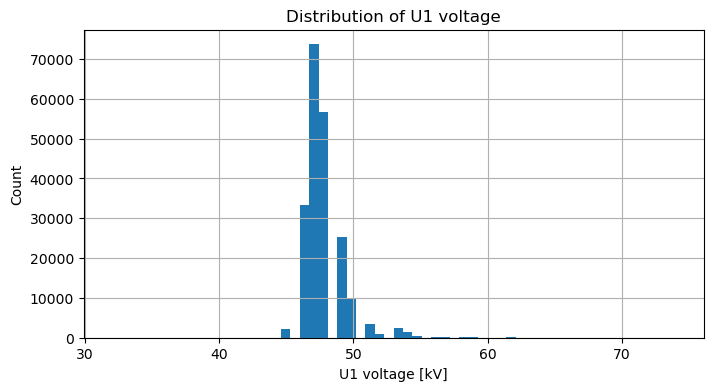

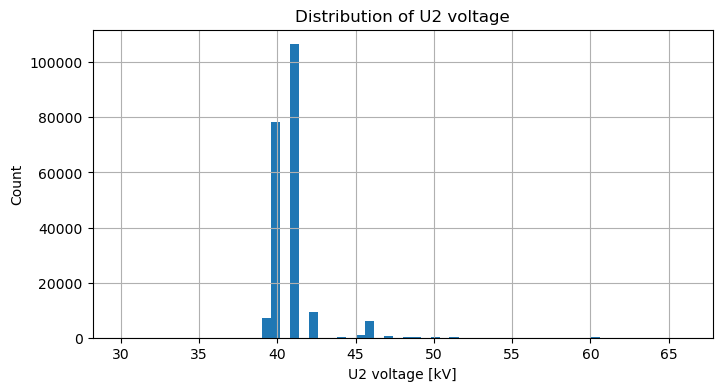

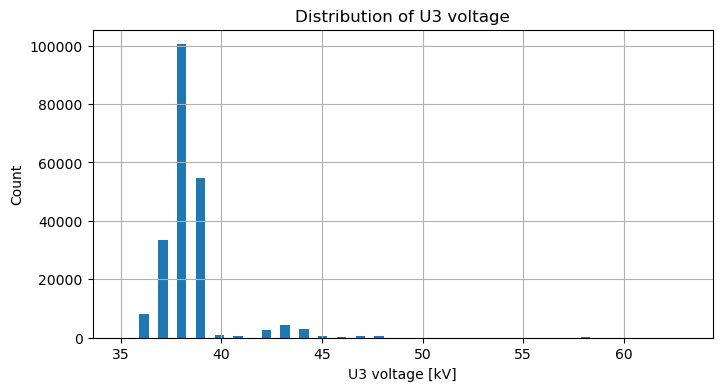

In [6]:
for name, col in U_COLS.items():
    plt.figure(figsize=(8, 4))
    plt.hist(df_ov[col].dropna(), bins=60)
    plt.xlabel(f"{name} voltage [kV]")
    plt.ylabel("Count")
    plt.title(f"Distribution of {name} voltage")
    plt.grid(True)
    plt.show()

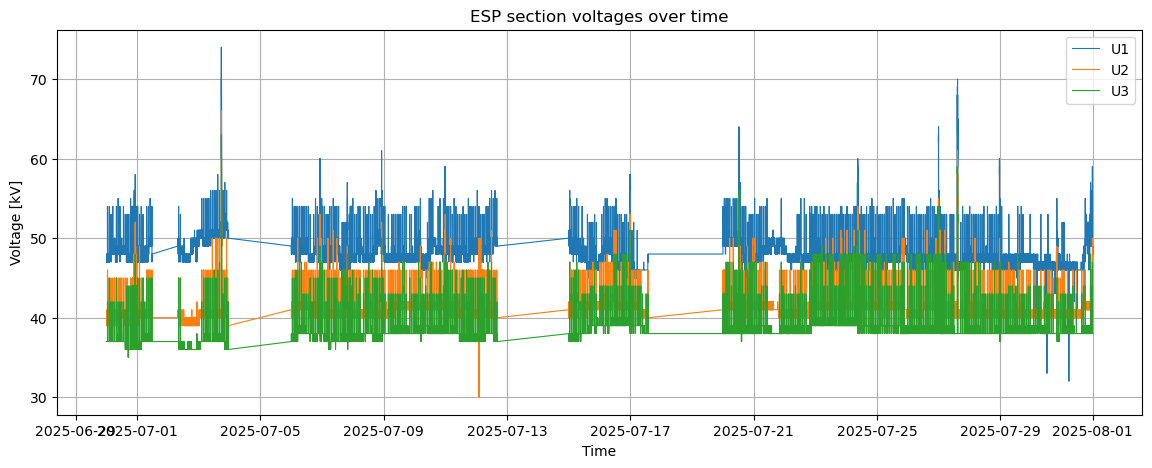

In [7]:
plt.figure(figsize=(14, 5))

for name, col in U_COLS.items():
    plt.plot(df_ov.index, df_ov[col], label=name, linewidth=0.8)

plt.xlabel("Time")
plt.ylabel("Voltage [kV]")
plt.title("ESP section voltages over time")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
samples_per_min = 6

for window_min in [1, 5, 15]:
    shift_n = window_min * samples_per_min
    
    for name, col in U_COLS.items():
        df_ov[f"{name}_delta_{window_min}min"] = df_ov[col] - df_ov[col].shift(shift_n)
    
    df_ov[f"U_mean_delta_{window_min}min"] = (
        df_ov["U_mean"] - df_ov["U_mean"].shift(shift_n)
    )

delta_cols = [
    col for col in df_ov.columns
    if "delta" in col and ("U" in col)
]

df_ov[delta_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
U1_delta_1min,210638.0,0.000028,0.981540,-14.000000,-5.0,-1.000000,0.0,0.0,0.0,1.000000,5.000000,14.000000
U2_delta_1min,210638.0,0.000028,0.978284,-20.000000,-5.0,-1.000000,0.0,0.0,0.0,1.000000,5.000000,16.000000
U3_delta_1min,210638.0,0.000028,0.983680,-6.000000,-5.0,0.000000,0.0,0.0,0.0,0.000000,5.000000,13.000000
U_mean_delta_1min,210638.0,0.000028,0.707042,-6.666667,-2.0,-1.000000,0.0,0.0,0.0,0.333333,3.666667,10.000000
U1_delta_5min,210614.0,0.000152,1.418233,-20.000000,-6.0,-1.000000,0.0,0.0,0.0,1.000000,6.000000,23.000000
U2_delta_5min,210614.0,0.000142,1.671324,-13.000000,-6.0,-1.000000,0.0,0.0,0.0,1.000000,6.000000,26.000000
U3_delta_5min,210614.0,0.000142,1.951302,-10.000000,-6.0,-5.000000,0.0,0.0,0.0,4.000000,6.000000,26.000000
U_mean_delta_5min,210614.0,0.000146,1.519321,-11.333333,-6.0,-1.666667,0.0,0.0,0.0,1.666667,5.666667,24.666667
U1_delta_15min,210554.0,0.001520,1.607602,-19.000000,-6.0,-1.000000,0.0,0.0,0.0,1.000000,6.000000,24.000000
U2_delta_15min,210554.0,0.001358,1.852888,-20.000000,-6.0,-1.000000,0.0,0.0,0.0,1.000000,6.000000,26.000000


In [9]:
voltage_change_rows = []

for window_min in [1, 5, 15]:
    for name in ["U1", "U2", "U3", "U_mean"]:
        delta_col = f"{name}_delta_{window_min}min"
        
        for threshold in [0.5, 1.0, 2.0, 5.0]:
            frac = (df_ov[delta_col].abs() >= threshold).mean()
            
            voltage_change_rows.append({
                "signal": name,
                "window_min": window_min,
                "threshold_kv": threshold,
                "fraction_abs_delta_above_threshold": frac,
            })

voltage_change_summary = pd.DataFrame(voltage_change_rows)

voltage_change_summary.pivot_table(
    index=["signal", "window_min"],
    columns="threshold_kv",
    values="fraction_abs_delta_above_threshold"
)

threshold_kv            0.5       1.0       2.0       5.0
signal window_min                                        
U1     1           0.163057  0.163057  0.030749  0.022032
       5           0.242471  0.242471  0.056379  0.045703
       15          0.294236  0.294236  0.065219  0.047972
U2     1           0.134768  0.134768  0.032477  0.026666
       5           0.216906  0.216906  0.081645  0.075345
       15          0.249549  0.249549  0.083354  0.077676
U3     1           0.097321  0.097321  0.043657  0.025849
       5           0.195230  0.195230  0.113030  0.098322
       15          0.216764  0.216764  0.116201  0.101531
U_mean 1           0.121048  0.081830  0.033929  0.004567
       5           0.178120  0.127281  0.086468  0.043025
       15          0.196103  0.133980  0.088861  0.045290

In [10]:
non_rapping_mask = (
    df_ov[RAPPING_TIME_COL].isna()
)

df_nonrap = df_ov.loc[non_rapping_mask].copy()

print("All samples:", len(df_ov))
print("Non-rapping samples:", len(df_nonrap))
print("Fraction non-rapping:", len(df_nonrap) / len(df_ov))

All samples: 210644
Non-rapping samples: 0
Fraction non-rapping: 0.0


In [11]:
# Pomocniczo: pokaż kolumny, które mogą być procesowe
candidate_process_keywords = [
    "016A",  # kocioł / proces
    "008A007",  # część temperatur / O2 / inne ESP, zależnie od mappingu
    "008A009",
]

candidate_cols = [
    col for col in df_nonrap.columns
    if any(key in col for key in candidate_process_keywords)
]

candidate_cols[:100], len(candidate_cols)

(['008A00936',
  '008A00910',
  '008A00911',
  '008A00720',
  '008A00728',
  '008A00719',
  '008A00727',
  '016A00219',
  '008A00723',
  '016A00396',
  '008A00731',
  '008A00741',
  '008A00742'],
 13)

In [12]:
exclude_cols = set(
    [TARGET_COL, "P_total", "P_total_calc", "U_mean", "U_sum"]
    + list(U_COLS.values())
    + list(I_COLS.values())
    + list(P_COLS.values())
    + [RAPPING_TIME_COL, RAPPING_FLAG_COL]
)

# Wykluczamy też kolumny wyliczone w tym notebooku
exclude_patterns = ["delta", "_calc", "_error"]

numeric_cols = df_nonrap.select_dtypes(include=[np.number]).columns.tolist()

process_feature_candidates = []

for col in numeric_cols:
    if col in exclude_cols:
        continue
    if any(pattern in col for pattern in exclude_patterns):
        continue
    
    # odrzucamy kolumny prawie stałe
    if df_nonrap[col].nunique(dropna=True) < 10:
        continue
    
    process_feature_candidates.append(col)

print("Number of process feature candidates:", len(process_feature_candidates))
process_feature_candidates[:50]

Number of process feature candidates: 0


[]

In [13]:
df_ov[[RAPPING_TIME_COL, RAPPING_FLAG_COL]].describe()

,minutes_since_rapping_3_collecting_start_0_5,is_within_5min_after_rapping_3_collecting
count,210644.000000,210644.000000
mean,-0.782118,0.062252
std,0.923827,0.241613
min,-1.000000,0.000000
25%,-1.000000,0.000000
50%,-1.000000,0.000000
75%,-1.000000,0.000000
max,5.000000,1.000000


In [14]:
df_ov[RAPPING_FLAG_COL].value_counts(dropna=False)

is_within_5min_after_rapping_3_collecting
0    197531
1     13113
Name: count, dtype: int64

In [15]:
# Poprawiona maska: poza znanym oknem 0–5 min po strzepywaniu
# Zakładamy, że RAPPING_FLAG_COL == 1 oznacza próbkę w oknie po strzepywaniu

non_rapping_mask = (
    df_ov[RAPPING_FLAG_COL].fillna(0).astype(int) == 0
)

df_nonrap = df_ov.loc[non_rapping_mask].copy()

print("All samples:", len(df_ov))
print("Non-rapping samples:", len(df_nonrap))
print("Fraction non-rapping:", len(df_nonrap) / len(df_ov))

df_nonrap[[TARGET_COL, "P_total", "U_mean"]].describe()

All samples: 210644
Non-rapping samples: 197531
Fraction non-rapping: 0.9377480488406981


,008A01345,P_total,U_mean
count,197531.000000,197531.000000,197531.000000
mean,10.811508,39.003098,42.169121
std,3.651407,8.372031,1.099094
min,2.000000,31.200000,37.333333
25%,9.000000,37.900000,41.666667
50%,11.000000,38.200001,42.000000
75%,12.000000,38.699999,42.333333
max,101.000000,288.699997,67.666667


In [16]:
PROCESS_COLS_CANDIDATE = [
    "008A00936",
    "008A00910",
    "008A00911",
    "008A00720",
    "008A00728",
    "008A00719",
    "008A00727",
    "016A00219",
    "008A00723",
    "016A00396",
    "008A00731",
    "008A00741",
    "008A00742",
]

PROCESS_COLS_CANDIDATE = [
    col for col in PROCESS_COLS_CANDIDATE
    if col in df_nonrap.columns
]

process_summary = df_nonrap[PROCESS_COLS_CANDIDATE].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T

process_summary["missing_frac"] = df_nonrap[PROCESS_COLS_CANDIDATE].isna().mean()

process_summary

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing_frac
008A00936,197531.0,31.991809,1.759655,20.1,29.50,30.10,31.00,31.700001,32.400002,36.00,38.900002,48.50,0.0
008A00910,197531.0,66445.485154,4948.947669,47811.0,57983.00,59481.00,63118.00,65841.000000,68892.000000,76168.00,82141.000000,95903.00,0.0
008A00911,197531.0,70959.698432,2939.646470,62280.0,66528.00,67566.00,68896.00,70264.000000,72530.000000,75964.00,80896.000000,100350.00,0.0
008A00720,197531.0,126.446274,3.957513,117.0,119.00,121.00,124.00,126.000000,129.000000,133.00,136.000000,144.00,0.0
008A00728,197531.0,127.085252,4.290023,117.0,119.00,121.00,124.00,127.000000,130.000000,135.00,138.000000,145.00,0.0
008A00719,197531.0,-0.662823,0.054208,-1.2,-0.84,-0.79,-0.68,-0.650000,-0.630000,-0.60,-0.580000,-0.48,0.0
008A00727,197531.0,-0.576951,0.053254,-1.1,-0.75,-0.70,-0.60,-0.570000,-0.540000,-0.51,-0.500000,-0.38,0.0
016A00219,197531.0,138.950352,6.144110,119.0,131.00,133.00,135.00,137.000000,141.000000,154.00,161.000000,191.00,0.0
008A00723,197531.0,15.333143,1.801914,11.0,12.00,13.00,14.00,15.000000,16.000000,19.00,20.000000,30.00,0.0
016A00396,197531.0,151.868790,5.234059,133.0,144.00,146.00,149.00,151.000000,154.000000,164.00,170.000000,196.00,0.0


In [17]:
mapping_paths = [
    DATA_PROCESSED / "tag_mapping.csv",
    PROJECT_ROOT / "data" / "raw" / "tag_mapping.csv",
    PROJECT_ROOT / "tag_mapping.csv",
]

tag_mapping_path = None

for p in mapping_paths:
    if p.exists():
        tag_mapping_path = p
        break

tag_mapping_path

WindowsPath('c:/Users/karol/Desktop/esp_industrial_ml/data/processed/tag_mapping.csv')

In [18]:
tag_mapping = pd.read_csv(tag_mapping_path)

tag_mapping.head()

,Nazwa;Opis;Symbol;Jednostka
0,008A00444;T wody zasilającej przed kotłem;08_T...
1,008A00936;N Czynna Generatora Kanal 1;08_TU_MO...
2,008A00910;F pow.do kotła Z/L;08_F_POWDOKOTL_Z_...
3,008A00911;F pow.do kotła Z/P;08_F_POWDOKOTL_Z_...
4,008A00720;T spalin za podgrz. pow. OPP str.L;0...


In [19]:
tag_mapping.columns

Index(['Nazwa;Opis;Symbol;Jednostka'], dtype='object')

In [20]:
for col in tag_mapping.columns:
    print(col)

Nazwa;Opis;Symbol;Jednostka


In [21]:
PROCESS_COLS = [
    "016A00219",
    "016A00396",
    "008A00719",
    "008A00720",
    "008A00723",
    "008A00727",
    "008A00728",
    "008A00731",
    "008A00910",
    "008A00911",
]

PROCESS_COLS = [
    col for col in PROCESS_COLS
    if col in df_nonrap.columns
]

PROCESS_COLS

['016A00219',
 '016A00396',
 '008A00719',
 '008A00720',
 '008A00723',
 '008A00727',
 '008A00728',
 '008A00731',
 '008A00910',
 '008A00911']

In [22]:
df_nonrap[PROCESS_COLS].describe(
    percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
016A00219,197531.0,138.950352,6.144110,119.0,131.00,133.00,135.00,137.00,141.00,154.00,161.00,191.00
016A00396,197531.0,151.868790,5.234059,133.0,144.00,146.00,149.00,151.00,154.00,164.00,170.00,196.00
008A00719,197531.0,-0.662823,0.054208,-1.2,-0.84,-0.79,-0.68,-0.65,-0.63,-0.60,-0.58,-0.48
008A00720,197531.0,126.446274,3.957513,117.0,119.00,121.00,124.00,126.00,129.00,133.00,136.00,144.00
008A00723,197531.0,15.333143,1.801914,11.0,12.00,13.00,14.00,15.00,16.00,19.00,20.00,30.00
008A00727,197531.0,-0.576951,0.053254,-1.1,-0.75,-0.70,-0.60,-0.57,-0.54,-0.51,-0.50,-0.38
008A00728,197531.0,127.085252,4.290023,117.0,119.00,121.00,124.00,127.00,130.00,135.00,138.00,145.00
008A00731,197531.0,15.550506,1.837207,11.0,13.00,13.00,14.00,16.00,17.00,19.00,21.00,30.00
008A00910,197531.0,66445.485154,4948.947669,47811.0,57983.00,59481.00,63118.00,65841.00,68892.00,76168.00,82141.00,95903.00
008A00911,197531.0,70959.698432,2939.646470,62280.0,66528.00,67566.00,68896.00,70264.00,72530.00,75964.00,80896.00,100350.00


In [23]:
overlap_cols = PROCESS_COLS + list(U_COLS.values()) + [TARGET_COL, "P_total", "U_mean"]

df_overlap = df_nonrap[overlap_cols].dropna().copy()

print("df_nonrap:", df_nonrap.shape)
print("df_overlap:", df_overlap.shape)
print("Fraction retained:", len(df_overlap) / len(df_nonrap))

df_nonrap: (197531, 97)
df_overlap: (197531, 16)
Fraction retained: 1.0


In [24]:
boiler_like_cols = [col for col in ["016A00219", "016A00396"] if col in df_overlap.columns]
boiler_like_cols

['016A00219', '016A00396']

In [25]:
for boiler_col in boiler_like_cols:
    tmp = df_overlap.copy()
    
    tmp["boiler_bin"] = pd.qcut(
        tmp[boiler_col],
        q=10,
        duplicates="drop"
    )
    
    grouped = tmp.groupby("boiler_bin").agg(
        n=("U_mean", "size"),
        U_mean_median=("U_mean", "median"),
        U_mean_std=("U_mean", "std"),
        U_mean_p05=("U_mean", lambda x: x.quantile(0.05)),
        U_mean_p95=("U_mean", lambda x: x.quantile(0.95)),
        dust_median=(TARGET_COL, "median"),
        P_total_median=("P_total", "median"),
    )
    
    grouped["U_mean_p95_minus_p05"] = grouped["U_mean_p95"] - grouped["U_mean_p05"]
    
    print("\nBoiler-like column:", boiler_col)
    display(grouped)


Boiler-like column: 016A00219


C:\Users\karol\AppData\Local\Temp\ipykernel_9764\3131162016.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = tmp.groupby("boiler_bin").agg(


,n,U_mean_median,U_mean_std,U_mean_p05,U_mean_p95,dust_median,P_total_median,U_mean_p95_minus_p05
boiler_bin,,,,,,,,
"(118.999, 134.0]",37817,42.000000,1.263947,41.333333,42.666667,9.0,38.099999,1.333333
"(134.0, 135.0]",22180,42.000000,0.467554,41.333333,42.666667,9.0,38.200000,1.333333
"(135.0, 136.0]",21340,42.000000,0.482435,41.333333,42.666667,9.0,38.100000,1.333333
"(136.0, 137.0]",18681,42.000000,0.913179,41.333333,42.666667,10.0,38.200001,1.333333
"(137.0, 139.0]",32392,42.000000,1.014127,41.333333,43.000000,10.0,38.299999,1.666667
"(139.0, 140.0]",14483,42.333333,1.557911,41.333333,43.333333,11.0,38.400001,2.000000
"(140.0, 141.0]",11352,42.333333,0.764932,41.333333,43.000000,12.0,38.400000,1.666667
"(141.0, 145.0]",20417,42.333333,0.868721,41.333333,43.000000,12.0,38.400000,1.666667
"(145.0, 191.0]",18869,42.333333,1.682963,41.000000,46.000000,14.0,38.700000,5.000000


C:\Users\karol\AppData\Local\Temp\ipykernel_9764\3131162016.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = tmp.groupby("boiler_bin").agg(



Boiler-like column: 016A00396


,n,U_mean_median,U_mean_std,U_mean_p05,U_mean_p95,dust_median,P_total_median,U_mean_p95_minus_p05
boiler_bin,,,,,,,,
"(132.999, 147.0]",28243,42.000000,0.880659,41.333333,42.666667,9.0,38.099999,1.333333
"(147.0, 148.0]",18265,42.000000,1.129370,41.333333,42.666667,9.0,38.200000,1.333333
"(148.0, 149.0]",22342,42.000000,0.996007,41.333333,42.666667,9.0,38.200000,1.333333
"(149.0, 150.0]",20555,42.000000,0.996792,41.333333,42.666667,9.0,38.200000,1.333333
"(150.0, 151.0]",23891,42.000000,1.041769,41.333333,43.000000,10.0,38.200001,1.666667
"(151.0, 152.0]",19624,42.000000,0.698775,41.333333,43.000000,11.0,38.299999,1.666667
"(152.0, 153.0]",15145,42.333333,1.048397,41.333333,43.000000,11.0,38.300000,1.666667
"(153.0, 154.0]",12583,42.333333,1.330621,41.333333,43.333333,11.0,38.499999,2.000000
"(154.0, 157.0]",17412,42.333333,0.950538,41.000000,43.333333,12.0,38.400001,2.333333


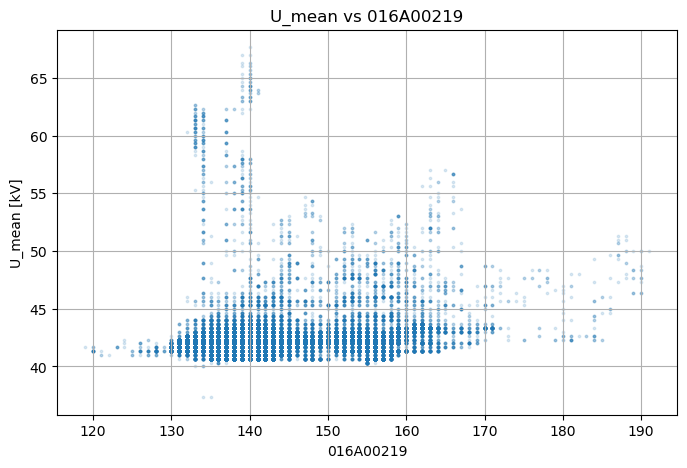

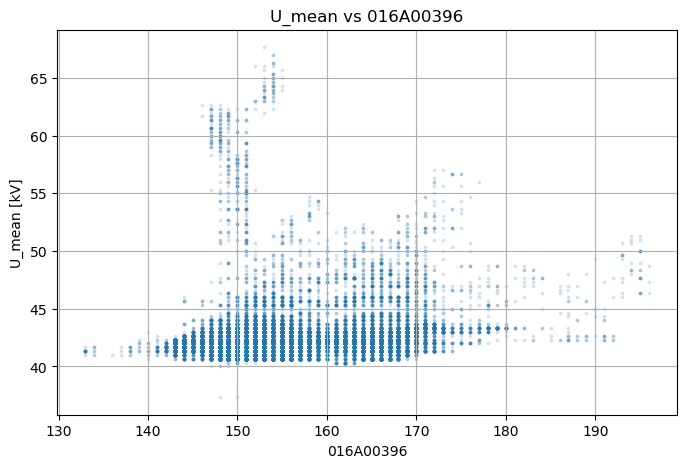

In [26]:
for boiler_col in boiler_like_cols:
    plt.figure(figsize=(8, 5))
    
    plt.scatter(
        df_overlap[boiler_col],
        df_overlap["U_mean"],
        s=3,
        alpha=0.15
    )
    
    plt.xlabel(boiler_col)
    plt.ylabel("U_mean [kV]")
    plt.title(f"U_mean vs {boiler_col}")
    plt.grid(True)
    plt.show()

In [27]:
tag_mapping = pd.read_csv(tag_mapping_path, sep=";")

tag_mapping.head()

,Nazwa,Opis,Symbol,Jednostka
0,008A00444,T wody zasilającej przed kotłem,08_T_WO_KOT,stC
1,008A00936,N Czynna Generatora Kanal 1,08_TU_MOCCZYNNGENK1,MW
2,008A00910,F pow.do kotła Z/L,08_F_POWDOKOTL_Z_L,Nm3/h
3,008A00911,F pow.do kotła Z/P,08_F_POWDOKOTL_Z_P,Nm3/h
4,008A00720,T spalin za podgrz. pow. OPP str.L,08_P_SPAPRZEZDELF_L,stC


In [28]:
tag_mapping.columns

Index(['Nazwa', 'Opis', 'Symbol', 'Jednostka'], dtype='object')

In [29]:
process_tag_descriptions = (
    tag_mapping
    .loc[tag_mapping["Nazwa"].isin(PROCESS_COLS)]
    .copy()
)

process_tag_descriptions

,Nazwa,Opis,Symbol,Jednostka
2,008A00910,F pow.do kotła Z/L,08_F_POWDOKOTL_Z_L,Nm3/h
3,008A00911,F pow.do kotła Z/P,08_F_POWDOKOTL_Z_P,Nm3/h
4,008A00720,T spalin za podgrz. pow. OPP str.L,08_P_SPAPRZEZDELF_L,stC
5,008A00728,T spalin za podgrz. pow. OPP str.P,08_T_SPAPRZEDELF_P,stC
9,008A00719,P spalin za podgrzewaczem pow. str. L,08_P_SPAZA_OPPL,kPa
10,008A00727,P spalin za podgrzewaczem pow. str. P,08_P_SPAZAOPP_P,kPa
17,016A00219,R1 P13 Moc czynna całkowita,16_R1P13PECA_PCZ,kW
18,008A00723,G kierownic WS1,08_SO_KIER_WS1,%
19,016A00396,R1 P18 Moc czynna całkowita,16_R1P18PECA_PCZ,kW
20,008A00731,G kierownic WS2,08_SO_KIER_WS2,%


In [30]:
process_tag_descriptions = (
    tag_mapping
    .loc[tag_mapping["Nazwa"].isin(PROCESS_COLS)]
    .set_index("Nazwa")
    .loc[PROCESS_COLS]
    .reset_index()
)

process_tag_descriptions

,Nazwa,Opis,Symbol,Jednostka
0,016A00219,R1 P13 Moc czynna całkowita,16_R1P13PECA_PCZ,kW
1,016A00396,R1 P18 Moc czynna całkowita,16_R1P18PECA_PCZ,kW
2,008A00719,P spalin za podgrzewaczem pow. str. L,08_P_SPAZA_OPPL,kPa
3,008A00720,T spalin za podgrz. pow. OPP str.L,08_P_SPAPRZEZDELF_L,stC
4,008A00720,T spalin za podgrz. pow. OPP str.L,08_P_SPAPRZEZDELF_L,stC
5,008A00723,G kierownic WS1,08_SO_KIER_WS1,%
6,008A00727,P spalin za podgrzewaczem pow. str. P,08_P_SPAZAOPP_P,kPa
7,008A00728,T spalin za podgrz. pow. OPP str.P,08_T_SPAPRZEDELF_P,stC
8,008A00728,T spalin za podgrz. pow. OPP str.P,08_T_SPAPRZEDELF_P,stC
9,008A00731,G kierownic WS2,08_SO_KIER_WS2,%


### Wstępna zmienność napięcia względem zmiennych obciążeniowych

Wstępna analiza w binach obciążenia wskazuje, że średnie napięcie ESP nie jest jednoznacznie determinowane przez zmienne powiązane z obciążeniem kotła. Dla większości binów lokalny zakres 5–95 percentyla `U_mean` wynosi około 1,3–2,3 kV, natomiast w binach najwyższego obciążenia zakres ten wzrasta do około 5 kV. Oznacza to, że dane historyczne zawierają pewną zmienność napięcia w porównywalnych warunkach obciążenia, ale overlap ma głównie charakter lokalny i zależny od reżimu pracy. Z tego względu nieograniczona optymalizacja napięć w szerokim zakresie byłaby wątpliwa, natomiast lokalne modyfikacje napięcia względem istniejącego punktu pracy ECO mogą być bardziej uzasadnione.

In [31]:
tmp = df_overlap.copy()

tmp["load_bin_1"] = pd.qcut(tmp["016A00219"], q=5, duplicates="drop")
tmp["load_bin_2"] = pd.qcut(tmp["016A00396"], q=5, duplicates="drop")

grouped_2d = tmp.groupby(["load_bin_1", "load_bin_2"], observed=True).agg(
    n=("U_mean", "size"),
    load_016A00219_median=("016A00219", "median"),
    load_016A00396_median=("016A00396", "median"),
    U_mean_median=("U_mean", "median"),
    U_mean_std=("U_mean", "std"),
    U_mean_p05=("U_mean", lambda x: x.quantile(0.05)),
    U_mean_p25=("U_mean", lambda x: x.quantile(0.25)),
    U_mean_p75=("U_mean", lambda x: x.quantile(0.75)),
    U_mean_p95=("U_mean", lambda x: x.quantile(0.95)),
    dust_median=(TARGET_COL, "median"),
    P_total_median=("P_total", "median"),
)

grouped_2d["U_mean_p95_minus_p05"] = (
    grouped_2d["U_mean_p95"] - grouped_2d["U_mean_p05"]
)

grouped_2d["U_mean_iqr"] = (
    grouped_2d["U_mean_p75"] - grouped_2d["U_mean_p25"]
)

grouped_2d = grouped_2d.sort_values("n", ascending=False)

grouped_2d.head(30)

,,n,load_016A00219_median,load_016A00396_median,U_mean_median,U_mean_std,U_mean_p05,U_mean_p25,U_mean_p75,U_mean_p95,dust_median,P_total_median,U_mean_p95_minus_p05,U_mean_iqr
load_bin_1,load_bin_2,,,,,,,,,,,,,
"(118.999, 135.0]","(132.999, 148.0]",41425,134.0,147.0,42.000000,1.031760,41.333333,41.666667,42.333333,42.666667,9.0,38.100000,1.333333,0.666667
"(141.0, 191.0]","(154.0, 196.0]",33922,148.0,159.0,42.333333,1.408999,41.000000,41.666667,42.666667,44.333333,13.0,38.599999,3.333333,1.000000
"(136.0, 139.0]","(150.0, 152.0]",29937,138.0,151.0,42.000000,0.933071,41.333333,41.666667,42.333333,43.000000,10.0,38.299999,1.666667,0.666667
"(118.999, 135.0]","(148.0, 150.0]",17366,135.0,149.0,42.000000,1.101174,41.333333,41.666667,42.333333,42.666667,9.0,38.100000,1.333333,0.666667
"(139.0, 141.0]","(152.0, 154.0]",16246,140.0,153.0,42.333333,1.292809,41.333333,42.000000,42.666667,43.333333,11.0,38.400000,2.000000,0.666667
"(136.0, 139.0]","(148.0, 150.0]",12837,137.0,150.0,42.333333,1.038047,41.333333,41.666667,42.333333,42.666667,10.0,38.299999,1.333333,0.666667
"(135.0, 136.0]","(148.0, 150.0]",12324,136.0,150.0,42.000000,0.478650,41.333333,41.666667,42.333333,42.666667,9.0,38.200000,1.333333,0.666667
"(136.0, 139.0]","(152.0, 154.0]",6462,139.0,153.0,42.333333,1.152256,41.333333,41.666667,42.333333,43.000000,10.0,38.300000,1.666667,0.666667
"(139.0, 141.0]","(150.0, 152.0]",6334,140.0,152.0,42.333333,1.068292,41.333333,42.000000,42.666667,43.000000,12.0,38.400000,1.666667,0.666667


In [32]:
reliable_cells = grouped_2d[grouped_2d["n"] >= 1000].copy()

print("Number of 2D cells:", len(grouped_2d))
print("Number of reliable 2D cells:", len(reliable_cells))

reliable_cells[
    [
        "n",
        "U_mean_std",
        "U_mean_p95_minus_p05",
        "U_mean_iqr",
        "dust_median",
        "P_total_median",
    ]
].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])

Number of 2D cells: 22
Number of reliable 2D cells: 15


,n,U_mean_std,U_mean_p95_minus_p05,U_mean_iqr,dust_median,P_total_median
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,13106.733333,0.875289,1.711111,0.666667,10.133333,38.293333
std,12621.652164,0.341285,0.547239,0.125988,1.505545,0.194446
min,1204.000000,0.358092,1.333333,0.333333,7.000000,38.100000
25%,4135.500000,0.499997,1.333333,0.666667,9.000000,38.100000
50%,6462.000000,1.031760,1.666667,0.666667,10.000000,38.299999
75%,16806.000000,1.084733,1.833333,0.666667,11.000000,38.400000
90%,32328.000000,1.236588,2.200000,0.666667,12.000000,38.560000
95%,36172.900000,1.327666,2.633333,0.766667,12.300000,38.630000
max,41425.000000,1.408999,3.333333,1.000000,13.000000,38.700000


In [33]:
overlap_cell_summary = pd.DataFrame({
    "criterion": [
        "U_mean p95-p05 >= 1 kV",
        "U_mean p95-p05 >= 2 kV",
        "U_mean p95-p05 >= 3 kV",
        "U_mean p95-p05 >= 5 kV",
    ],
    "fraction_of_reliable_cells": [
        (reliable_cells["U_mean_p95_minus_p05"] >= 1).mean(),
        (reliable_cells["U_mean_p95_minus_p05"] >= 2).mean(),
        (reliable_cells["U_mean_p95_minus_p05"] >= 3).mean(),
        (reliable_cells["U_mean_p95_minus_p05"] >= 5).mean(),
    ],
    "fraction_of_samples_in_reliable_cells": [
        reliable_cells.loc[reliable_cells["U_mean_p95_minus_p05"] >= 1, "n"].sum() / reliable_cells["n"].sum(),
        reliable_cells.loc[reliable_cells["U_mean_p95_minus_p05"] >= 2, "n"].sum() / reliable_cells["n"].sum(),
        reliable_cells.loc[reliable_cells["U_mean_p95_minus_p05"] >= 3, "n"].sum() / reliable_cells["n"].sum(),
        reliable_cells.loc[reliable_cells["U_mean_p95_minus_p05"] >= 5, "n"].sum() / reliable_cells["n"].sum(),
    ],
})

overlap_cell_summary

,criterion,fraction_of_reliable_cells,fraction_of_samples_in_reliable_cells
0,U_mean p95-p05 >= 1 kV,1.000000,1.000000
1,U_mean p95-p05 >= 2 kV,0.266667,0.295029
2,U_mean p95-p05 >= 3 kV,0.066667,0.172542
3,U_mean p95-p05 >= 5 kV,0.000000,0.000000


In [34]:
U_MEAN_LOW = df_overlap["U_mean"].quantile(0.01)
U_MEAN_HIGH = df_overlap["U_mean"].quantile(0.99)

df_overlap_typical_u = df_overlap[
    (df_overlap["U_mean"] >= U_MEAN_LOW)
    & (df_overlap["U_mean"] <= U_MEAN_HIGH)
].copy()

print("U_mean 1%:", U_MEAN_LOW)
print("U_mean 99%:", U_MEAN_HIGH)
print("Original:", len(df_overlap))
print("Typical U:", len(df_overlap_typical_u))
print("Removed:", len(df_overlap) - len(df_overlap_typical_u))

U_mean 1%: 40.666666666666664
U_mean 99%: 45.666666666666664
Original: 197531
Typical U: 195665
Removed: 1866


In [35]:
tmp = df_overlap_typical_u.copy()

tmp["load_bin_1"] = pd.qcut(tmp["016A00219"], q=5, duplicates="drop")
tmp["load_bin_2"] = pd.qcut(tmp["016A00396"], q=5, duplicates="drop")

grouped_2d_typical_u = tmp.groupby(["load_bin_1", "load_bin_2"], observed=True).agg(
    n=("U_mean", "size"),
    U_mean_median=("U_mean", "median"),
    U_mean_std=("U_mean", "std"),
    U_mean_p05=("U_mean", lambda x: x.quantile(0.05)),
    U_mean_p95=("U_mean", lambda x: x.quantile(0.95)),
    dust_median=(TARGET_COL, "median"),
    P_total_median=("P_total", "median"),
)

grouped_2d_typical_u["U_mean_p95_minus_p05"] = (
    grouped_2d_typical_u["U_mean_p95"] - grouped_2d_typical_u["U_mean_p05"]
)

reliable_cells_typical_u = grouped_2d_typical_u[
    grouped_2d_typical_u["n"] >= 1000
].copy()

reliable_cells_typical_u[
    [
        "n",
        "U_mean_std",
        "U_mean_p95_minus_p05",
        "dust_median",
        "P_total_median",
    ]
].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95])

,n,U_mean_std,U_mean_p95_minus_p05,dust_median,P_total_median
count,15.000000,15.000000,15.000000,15.000000,15.000000
mean,12984.733333,0.522557,1.644444,10.133333,38.293333
std,12453.762050,0.100528,0.366595,1.505545,0.194446
min,1204.000000,0.358092,1.333333,7.000000,38.100000
25%,4109.500000,0.456576,1.333333,9.000000,38.100000
50%,6439.000000,0.499170,1.666667,10.000000,38.299999
75%,16722.000000,0.566644,1.833333,11.000000,38.400000
90%,31554.400000,0.624375,2.200000,12.000000,38.560000
95%,35282.000000,0.669471,2.333333,12.300000,38.630000
max,41302.000000,0.766419,2.333333,13.000000,38.700000
